# Se positionner grâce à une balise



Se positionner grâce à une balise

Se positionner grâce à une baliseSe positionner grâce à une balise

## Balise

Une balise est un élément physique conçu pour être aisément reconnaissable et dont la position est fixe ou du moins connu. 

Pour nos exemples, la balise est un cylindre à la verticale. Sa base circulaire permet de modéliser une balise par un obstacle en forme de cercle. 

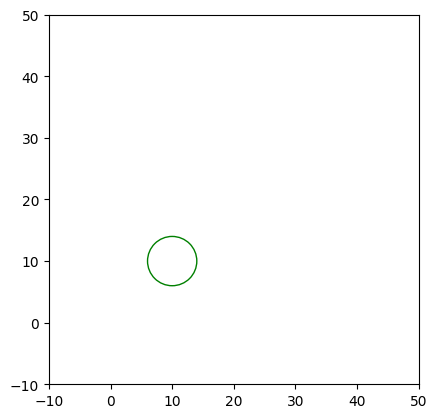

In [1]:
import matplotlib.pyplot as plt

from slam_robot.models.beacon import CylinderBeacon

beacon_1 = CylinderBeacon()
# Nous définissons ici une balise dont la position est (10, 10) et le rayon de 4 cm. Cette balise porte l'indice n° 1.
beacon_1.set_parameters(10, 10, 4, 0)

# afficher le cylindre
ax = plt.axes()
beacon_1.draw(ax)
ax.set_xlim([-10, 50])
ax.set_ylim([-10, 50])
ax.set_aspect('equal', adjustable='box')
plt.show()


Nous allons placer maintenant le robot avec son lidar (représenté en rouge).

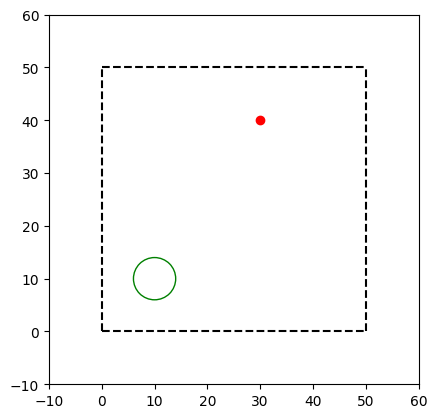

In [2]:
import matplotlib.pyplot as plt
from slam_robot.models.beacon import CylinderBeacon
from slam_robot.utils.geometry import Point
from slam_robot.models.robot import Robot
from slam_robot.models.world import World

fix, ax = plt.subplots()

beacon_1 = CylinderBeacon()
beacon_1.set_parameters(10, 10, 4, 0)

initial_position = Point(30, 40)
initial_orientation = 0


world = World([
    beacon_1,
], 50, 50)
ax.set_aspect('equal', adjustable='box')
world.draw(ax)

robot = Robot(initial_position, initial_orientation)
plt.scatter([robot.position.x], [robot.position.y], color="red")

La représentation des mesures se fait en projetant le centre du robot sur tous les obstacles autour de lui. Le seul obstacle ici est la balise.

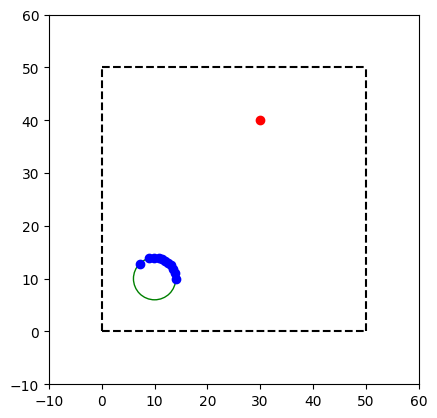

In [3]:
import matplotlib.pyplot as plt

from slam_robot.models.action import Sense
from slam_robot.models.beacon import CylinderBeacon
from slam_robot.models.robot import Robot
from slam_robot.models.world import World
from slam_robot.utils.geometry import Point

fix, ax = plt.subplots()

beacon_1 = CylinderBeacon()
beacon_1.set_parameters(10, 10, 4, 0)

initial_position = Point(30, 40)
initial_orientation = 0


world = World([
    beacon_1,
], 50, 50)
ax.set_aspect('equal', adjustable='box')
world.draw(ax)

robot = Robot(initial_position, initial_orientation)
plt.scatter([robot.position.x], [robot.position.y], color="red")

# Le robot effectue une mesure à sa position initiale.
robot.apply_actions([Sense()], world)
x_values = []
y_values = []
for measure in robot.measures:
    for point in measure.obstacles:
        x_values.append(point.x)
        y_values.append(point.y)
plt.scatter(x_values, y_values, color="blue")

Le robot n'a accès qu'à la rangée de points en bleu.

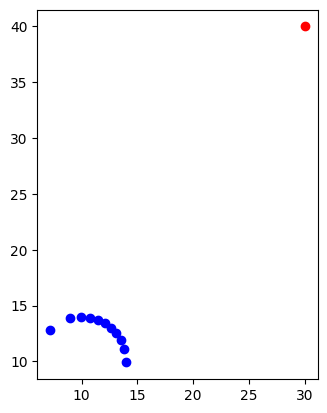

In [4]:
import matplotlib.pyplot as plt

from slam_robot.models.action import Sense
from slam_robot.models.beacon import CylinderBeacon
from slam_robot.models.robot import Robot
from slam_robot.models.world import World
from slam_robot.utils.geometry import Point

fix, ax = plt.subplots()

beacon_1 = CylinderBeacon()
beacon_1.set_parameters(10, 10, 4, 0)

initial_position = Point(30, 40)
initial_orientation = 0


world = World([
    beacon_1,
], 50, 50)
ax.set_aspect('equal', adjustable='box')
robot = Robot(initial_position, initial_orientation)
plt.scatter([robot.position.x], [robot.position.y], color="red")

# Le robot effectue une mesure à sa position initiale.
robot.apply_actions([Sense()], world)
x_values = []
y_values = []
for measure in robot.measures:
    for point in measure.obstacles:
        x_values.append(point.x)
        y_values.append(point.y)
plt.scatter(x_values, y_values, color="blue")

Comment savoir que la rangée de points correspond à la balise que l'on a défini ? Il faut en revenir aux propriétés de la balise pour la caractériser : c'est un cylindre de rayon 4 cm. La rangée de points décrit donc un arc de cercle dont le rayon est de 4 cm.
L'idée est de trouver le point qui minimise sa distance à tous les autres points mesurées par le lidar. 

:::{math}
\min_{X}{\sum_{i = 0}^{n}{(d(M_i, X) - r)^2}}
:::

Le problème géométrique est devenu un problème d'optimisation. Nous utilisons ici la méthode des moindres carrés de Levenberg-Marquart.

L'efficacité de cette méthode dépend du nombre de points mesurés.

Il est envisageable de tester l'efficacité de la méthode en simulant avec comme variable le nombre de points accessibles pour les tests.

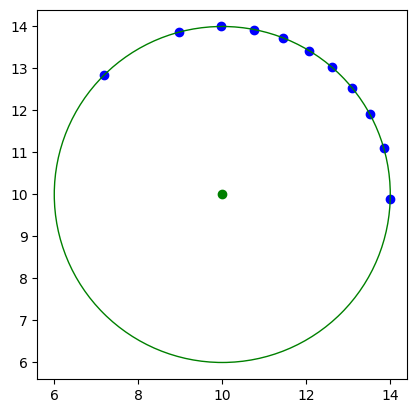

In [5]:
from slam_robot.models.cluster import Cluster

import matplotlib.pyplot as plt

from slam_robot.models.action import Sense
from slam_robot.models.beacon import CylinderBeacon
from slam_robot.models.robot import Robot
from slam_robot.models.world import World
from slam_robot.utils.geometry import Point
from slam_robot.models.world_items import Circle

fix, ax = plt.subplots()

beacon_1 = CylinderBeacon()
beacon_1.set_parameters(10, 10, 4, 0)

initial_position = Point(30, 40)
initial_orientation = 0


world = World([
    beacon_1,
], 50, 50)
ax.set_aspect('equal', adjustable='box')
robot = Robot(initial_position, initial_orientation)

# Le robot effectue une mesure à sa position initiale.
robot.apply_actions([Sense()], world)
x_values = []
y_values = []

cluster = Cluster()
for measure in robot.measures:
    for point in measure.obstacles:
        x_values.append(point.x)
        y_values.append(point.y)
        cluster.append(point)
plt.scatter(x_values, y_values, color="blue")

res = cluster.is_a_circle(4)
result = Point.from_array(res.x)

plt.scatter([result.x], [result.y], color="green")

circle = Circle(result, 4)
circle.draw(ax)






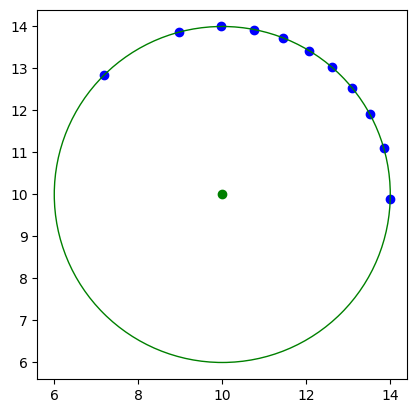

In [6]:
from slam_robot.models.cluster import Cluster

import matplotlib.pyplot as plt

from slam_robot.models.action import Sense
from slam_robot.models.beacon import CylinderBeacon
from slam_robot.models.robot import Robot
from slam_robot.models.world import World
from slam_robot.utils.geometry import Point
from slam_robot.models.world_items import Circle

fix, ax = plt.subplots()

beacon_1 = CylinderBeacon()
beacon_1.set_parameters(10, 10, 4, 0)

initial_position = Point(30, 40)
initial_orientation = 0


world = World([
    beacon_1,
], 50, 50)
ax.set_aspect('equal', adjustable='box')
robot = Robot(initial_position, initial_orientation)

# Le robot effectue une mesure à sa position initiale.
robot.apply_actions([Sense()], world)
x_values = []
y_values = []

cluster = Cluster()
for measure in robot.measures:
    for point in measure.obstacles:
        x_values.append(point.x)
        y_values.append(point.y)
        cluster.append(point)
plt.scatter(x_values, y_values, color="blue")

res = cluster.is_a_circle(4)
result = Point.from_array(res.x)

plt.scatter([result.x], [result.y], color="green")

circle = Circle(result, 4)
circle.draw(ax)


On s'aperçoit que le centre est parfaitement trouvé.

Plus sérieusement, on peut contrôler la précision du résultat.

Nous avons donc retrouvé la position du cercle. Nous avons récupéré une rangée de points à partir d'un lidar, dont nous avons vu le fonctionnement, et nous sommes parvenu à retrouver la position relative d'une balise dont la position absolue était connue, de sorte que la position absolue du robot peut être retrouvée.

## Retrouver la position du robot

On suppose l'existence d'un repaère cartésien extérieur. Les grandeurs avec un exposant e sont ceux données dans ce repère extérieur.

Nous confondons la position du robot et son orientation avec ceux du lidar. Autrement dit, $(x_l^e, y_l^e, \theta_R^e) = (x_R^e, y_R^e, \theta_R^e)$.

Supposons que la position de la balise soit $(x_b^e, y_b^e)$ dans un repère cartésien extérieur. Grâce au lidar, nous avons aussi la position de la balise dans son repère $(x_b^l, y_b^l)$.



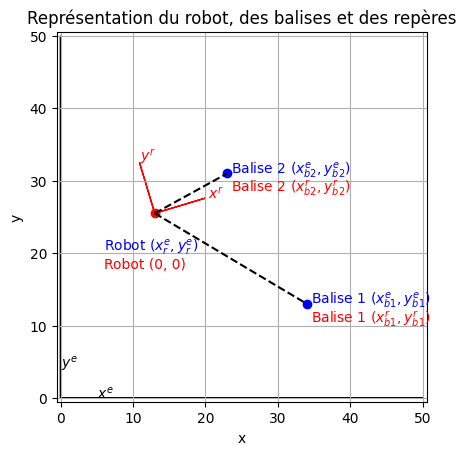

In [44]:
import numpy as np
import matplotlib.pyplot as plt

# --- Création de la figure ---
fig, ax = plt.subplots()
ax.set_aspect('equal')

# --- Repère monde ---
ax.arrow(0, 0, 50, 0, head_width=0.1, length_includes_head=True)
ax.arrow(0, 0, 0, 50, head_width=0.1, length_includes_head=True)
ax.text(5.1, 0, r"$x^e$")
ax.text(0, 4.1, r"$y^e$")

# --- Position du robot ---
robot = np.array([13.0, 25.5])
ax.plot(robot[0], robot[1], 'ro')
ax.text(robot[0] - 7, robot[1]-7.6, "Robot (0, 0)", color='red')
ax.text(robot[0] - 7, robot[1]-5.2, "Robot $(x_r^e, y_r^e$)", color='blue')

# --- Repère robot ---
ax.arrow(robot[0], robot[1], 7*1.0, 7*0.3,
         head_width=0.08, length_includes_head=True, color='red')
ax.arrow(robot[0], robot[1], -7*0.3, 7*1.0,
         head_width=0.08, length_includes_head=True, color='red')
ax.text(robot[0] + 7*1.05, robot[1] + 7*0.3, r"$x^r$", color='red')
ax.text(robot[0] - 7*0.3, robot[1] + 7*1.05, r"$y^r$", color='red')

# --- Balises --3
balise1 = np.array([34.0, 13.0])
balise2 = np.array([23.0, 31.0])

ax.plot(balise1[0], balise1[1], 'bo')
ax.plot(balise2[0], balise2[1], 'bo')

ax.text(balise1[0] + 0.5, balise1[1], "Balise 1 $(x_{b1}^e, y_{b1}^e)$", color='blue')
ax.text(balise1[0] + 0.5, balise1[1]-2.5, "Balise 1 $(x_{b1}^r, y_{b1}^r)$", color='red')
ax.text(balise2[0] + 0.5, balise2[1], "Balise 2 $(x_{b2}^e, y_{b2}^e)$", color='blue')
ax.text(balise2[0] + 0.5, balise2[1]-2.5, "Balise 2 $(x_{b2}^r, y_{b2}^r)$", color='red')

# --- Mesures lidar (segments pointillés) ---
ax.plot([robot[0], balise1[0]], [robot[1], balise1[1]], 'k--')
ax.plot([robot[0], balise2[0]], [robot[1], balise2[1]], 'k--')

# --- Mise en forme ---
ax.set_xlim(-0.5, 50.5)
ax.set_ylim(-0.5, 50.5)
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_title("Représentation du robot, des balises et des repères")

plt.grid(True)
plt.show()


## Bibliographie

* [optimize.root-lm](https://docs.scipy.org/doc/scipy/reference/optimize.root-lm.html) - Documentation de `scipy`.
* [Algorithme de Levenberg-Marquardt](https://fr.wikipedia.org/wiki/Algorithme_de_Levenberg-Marquardt) - Algorithme de Levenberg-Marquardt.
* [OptimizeResult](https://docs.scipy.org/doc/scipy/reference/generated/scipy.optimize.OptimizeResult.html) - OptimizeResult